In [21]:
from cmath import nan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('player_data.csv')
df.head()

,name,year_start,year_end,position,height,weight,birth_date,college
0,Alaa Abdelnaby,1991,1995,F-C,6-10,240.0,"June 24, 1968",Duke University
1,Zaid Abdul-Aziz,1969,1978,C-F,6-9,235.0,"April 7, 1946",Iowa State University
2,Kareem Abdul-Jabbar,1970,1989,C,7-2,225.0,"April 16, 1947","University of California, Los Angeles"
3,Mahmoud Abdul-Rauf,1991,2001,G,6-1,162.0,"March 9, 1969",Louisiana State University
4,Tariq Abdul-Wahad,1998,2003,F,6-6,223.0,"November 3, 1974",San Jose State University


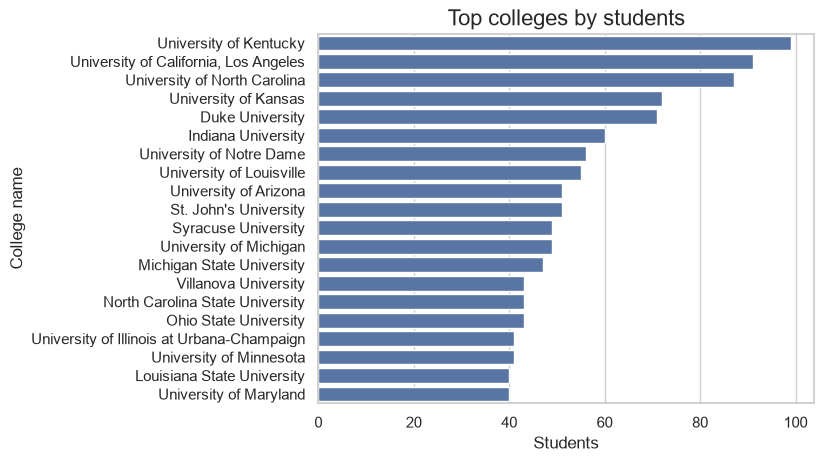

In [80]:
df_college_counts = df['college'].value_counts().nlargest(20).reset_index()

sns.barplot(
    data=df_college_counts,
    x='count',
    y='college',
)

plt.title('Top colleges by students', fontsize=16)
plt.xlabel('Students', fontsize=12)
plt.ylabel('College name', fontsize=12)

plt.show()

# This barplot shows top 20 colleges by their student's count

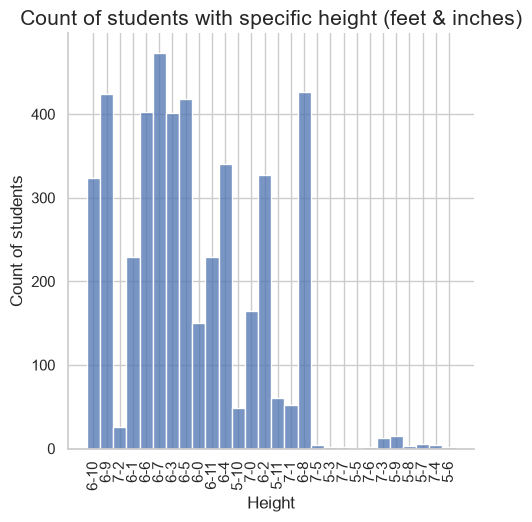

In [82]:
sns.displot(
    data=df,
    x = 'height',
)

plt.title('Count of students with specific height (feet & inches)', fontsize = 15)
plt.xlabel('Height', fontsize = 12)
plt.ylabel('Count of students', fontsize = 12)

plt.xticks(rotation = 90)
plt.show()

# This displot shows amount of students grouped by their height

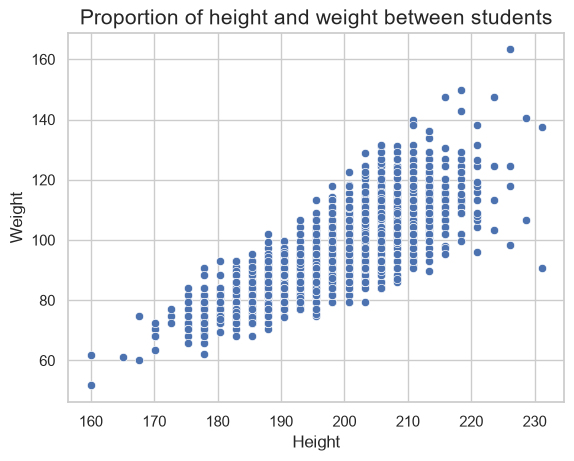

In [77]:
def feet_to_cm(height_str):
    if not isinstance(height_str, str):
        return np.nan

    feet, inches = map(int, height_str.split('-'))
    return (feet * 30.48) + (inches * 2.54)

df['height_cm'] = df['height'].apply(feet_to_cm)
df['weight_kg'] = df['weight'] / 2.205

sns.scatterplot(
    data=df,
    x = 'height_cm',
    y = 'weight_kg'
)

plt.title('Proportion of height and weight between students', fontsize = 15)
plt.xlabel('Height', fontsize = 12)
plt.ylabel('Weight', fontsize = 12)

plt.show()

# This scatter plot shows student's height and which weight people with that height have

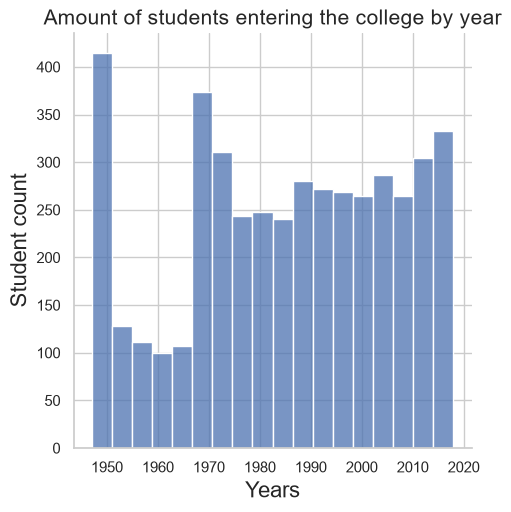

In [83]:
sns.displot(
    data=df,
    x = 'year_start'
)

plt.title('Amount of students entering the college by year', fontsize = 15)
plt.xlabel('Years', fontsize = 16)
plt.ylabel('Student count', fontsize = 16)
plt.show()

# This displot shows when students start entering their colleges

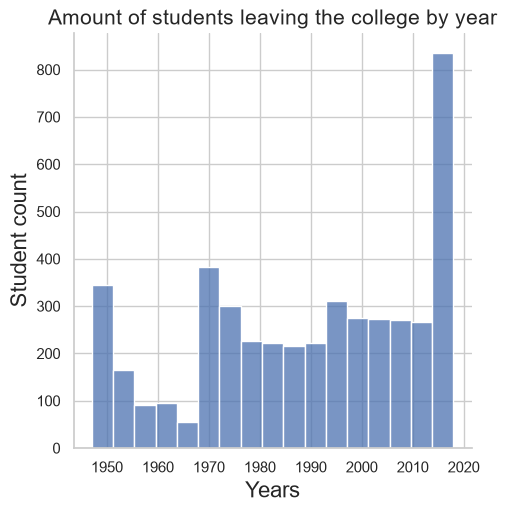

In [84]:
sns.displot(
    data=df,
    x = 'year_end'
)

plt.title('Amount of students leaving the college by year', fontsize = 15)
plt.xlabel('Years', fontsize = 16)
plt.ylabel('Student count', fontsize = 16)
plt.show()

# This displot shows when students end their colleges

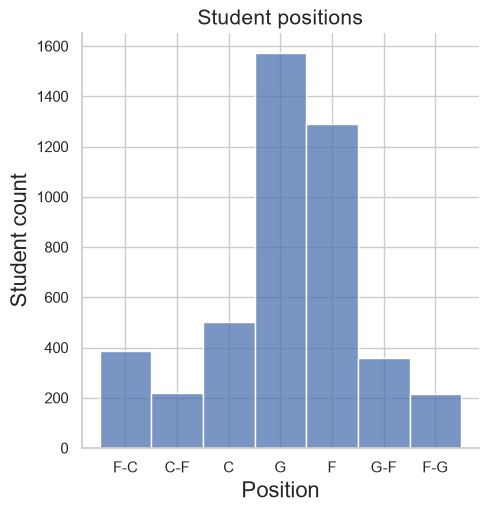

In [86]:
sns.displot(
    data=df,
    x = 'position'
)

plt.title('Student positions', fontsize = 15)
plt.xlabel('Position', fontsize = 16)
plt.ylabel('Student count', fontsize = 16)
plt.show()

# This displot shows student's positions in all colleges

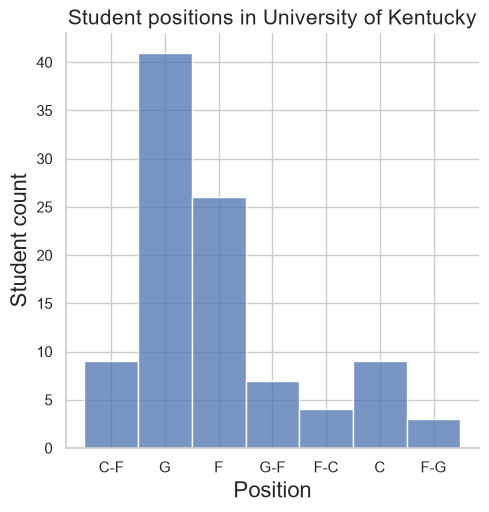

In [88]:
sns.displot(
    data=df[df['college'] == 'University of Kentucky'],
    x = 'position'
)

plt.title('Student positions in University of Kentucky', fontsize = 15)
plt.xlabel('Position', fontsize = 16)
plt.ylabel('Student count', fontsize = 16)
plt.show()

# This displot shows student's positions only in University of Kentucky

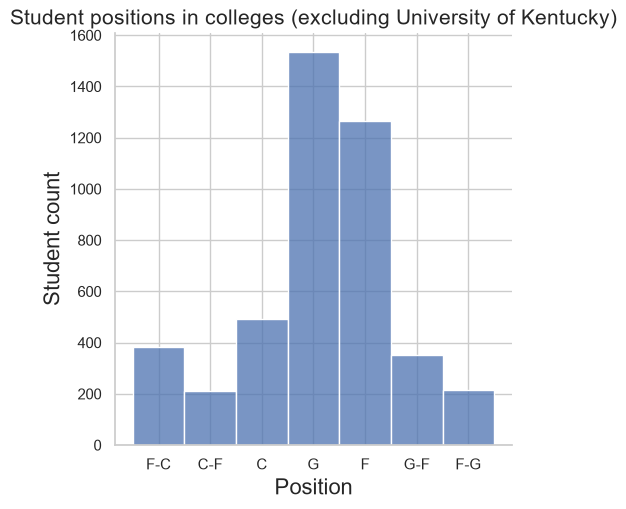

In [90]:
sns.displot(
    data=df[df['college'] != 'University of Kentucky'],
    x = 'position'
)

plt.title('Student positions in colleges (excluding University of Kentucky)', fontsize = 15)
plt.xlabel('Position', fontsize = 16)
plt.ylabel('Student count', fontsize = 16)
plt.show()

# This displot shows student's positions in all colleges excluding University of Kentucky

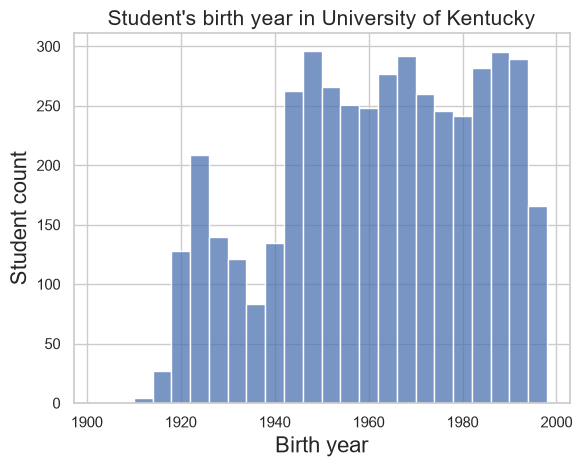

In [98]:
def getBirthYear(birth_date):
    if not isinstance(birth_date, str):
        return np.nan

    return int(birth_date[-4:])

df['birth_year'] = df['birth_date'].apply(getBirthYear)
sns.histplot(
    data=df[df['college'] == 'University of Kentucky'],
    x = df['birth_year']
)

plt.title('Student\'s birth year in University of Kentucky', fontsize = 15)
plt.xlabel('Birth year', fontsize = 16)
plt.ylabel('Student count', fontsize = 16)
plt.show()

# This displot shows student's birth year in University of Kentucky

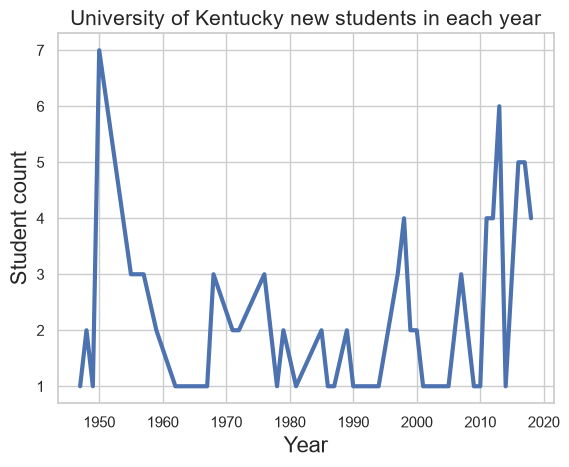

In [108]:
df_filtered = df[df['college'] == 'University of Kentucky']

df_yearly_counts = df_filtered['year_start'].value_counts().sort_index().reset_index()

sns.lineplot(
    data = df_yearly_counts,
    x = 'year_start',
    y = 'count',
    linewidth = 3,
)

plt.title('University of Kentucky new students in each year', fontsize = 15)
plt.xlabel('Year', fontsize = 16)
plt.ylabel('Student count', fontsize = 16)
plt.show()